In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

In [ ]:
from google.colab import files

uploaded=files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (2).zip",'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
os.listdir("/content/")

['.config',
 'val',
 'archive (2).zip',
 'val.csv',
 'train',
 'train.csv',
 'sample_data']

In [ ]:
os.listdir("/content/train")

['cat', 'classname.txt', 'dog']

In [ ]:
os.listdir("/content/val")

['cat', 'classname.txt', 'dog']

In [ ]:
train_path="/content/train"

val_path="/content/val"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_generator=ImageDataGenerator(

            rescale=1./255

)

In [ ]:
val_generator=ImageDataGenerator(

            rescale=1./255

)

In [ ]:
train_data=train_generator.flow_from_directory(

            train_path,

            target_size=(128,128),

            batch_size=32,

            class_mode='binary'

)

Found 275 images belonging to 2 classes.


In [ ]:
val_data=val_generator.flow_from_directory(

            val_path,

            target_size=(128,128),

            batch_size=32,

            class_mode='binary'

)

Found 70 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

In [ ]:
model=models.Sequential()

In [ ]:
model.add(

layers.Conv2D(

32,

(3,3),

activation='relu',

input_shape=(128,128,3)

))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(

layers.MaxPooling2D(2,2)

)

In [ ]:
model.add(

layers.Conv2D(

64,

(3,3),

activation='relu'

))

model.add(

layers.MaxPooling2D(2,2)

)

In [ ]:
model.add(

layers.Conv2D(

128,

(3,3),

activation='relu'

))

model.add(

layers.MaxPooling2D(2,2)

)

In [ ]:
model.add(

layers.Flatten()

)

In [ ]:
model.add(

layers.Dense(

128,

activation='relu'

))



In [ ]:
model.add(

layers.Dropout(0.5)

)

In [ ]:
model.add(

layers.Dense(

1,

activation='sigmoid'

))



In [ ]:
model.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']

)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(

        train_data,

        epochs=10,

        validation_data=val_data

)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5709 - loss: 0.7856 - val_accuracy: 0.6571 - val_loss: 0.6549
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 913ms/step - accuracy: 0.6545 - loss: 0.6350 - val_accuracy: 0.6571 - val_loss: 0.6294
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6509 - loss: 0.6271 - val_accuracy: 0.6571 - val_loss: 0.6495
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6655 - loss: 0.6044 - val_accuracy: 0.6571 - val_loss: 0.6318
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 915ms/step - accuracy: 0.6582 - loss: 0.5964 - val_accuracy: 0.6571 - val_loss: 0.6369
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 915ms/step - accuracy: 0.6800 - loss: 0.5647 - val_accuracy: 0.6571 - val_loss: 0.6494
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6691 - loss: 0.5259 - val_accuracy: 0.6571 - val_loss: 0.6732
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8036 - loss: 0.4691 - val_accuracy: 0.6429 - val_loss: 0.6789
E

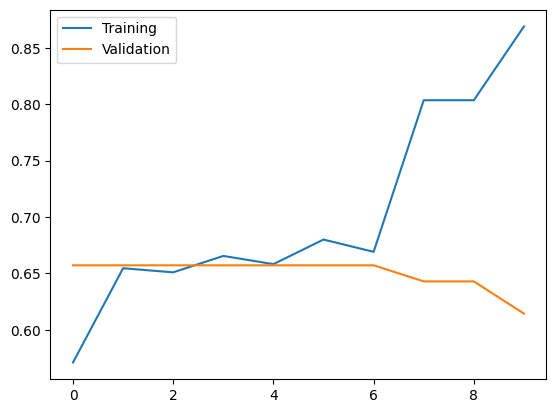

In [ ]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(

['Training','Validation']

)

plt.show()

In [ ]:
model.save("cat_dog_model.h5")

In [ ]:
from google.colab import files

files.download("cat_dog_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Loss =", loss)
print("Accuracy =", accuracy*100,"%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.6143 - loss: 0.7492
Loss = 0.7492094039916992
Accuracy = 61.42857074737549 %


In [ ]:
model.save("cat_dog_model.h5")

In [ ]:
import os

os.listdir()

['.config',
 'val',
 'cat_dog_model.h5',
 'archive (2).zip',
 'val.csv',
 'train',
 'train.csv',
 'sample_data']

In [ ]:
from google.colab import files

files.download("cat_dog_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [ ]:
import os

print(os.listdir("/content/train/cat")[:10])

['Sphynx_151_jpg.rf.b3bff7789918d2a492e2e0b9a20d7e6c.jpg', 'British_Shorthair_193_jpg.rf.ab376d75fb05acc1ec59f06228ebe5bb.jpg', 'Ragdoll_160_jpg.rf.625334e2d1ce3b4e412899793b2da250.jpg', 'Bombay_125_jpg.rf.c91236394fb2adb244ba8866b53dbd43.jpg', 'Abyssinian_15_jpg.rf.7bc44eeb9865e35cb1d5f9ef4f53b381.jpg', 'Bengal_103_jpg.rf.bb684501a53abf381a6bf07f9cd2243c.jpg', 'Bengal_145_jpg.rf.3dadbfbb39437890fc249f7edb37cb2f.jpg', 'Sphynx_177_jpg.rf.38e052693b96ad306bc8588d1a7d89c3.jpg', 'Russian_Blue_147_jpg.rf.c7b83af53e13c033c64b22c723524201.jpg', 'Bengal_165_jpg.rf.31185846cf5892c6e7e3f02784e04fef.jpg']


In [ ]:
print(os.listdir("/content/train/dog")[:10])

['american_bulldog_149_jpg.rf.2e1409cf0481360ea7dea93bc4f66f45.jpg', 'american_pit_bull_terrier_116_jpg.rf.9580b685328d6659a2765ac8d933d503.jpg', 'shiba_inu_199_jpg.rf.4e0f1a314018e84aad8a33b12e7faf5e.jpg', 'pug_185_jpg.rf.ab25dd1add392dc8b35533071deabc3a.jpg', 'great_pyrenees_111_jpg.rf.67c3210e8a31d0573d4b27f20dd1e1d6.jpg', 'american_bulldog_176_jpg.rf.92f96e4ec1bccbdbc8243c6888ca10ff.jpg', 'saint_bernard_132_jpg.rf.04a44922afead0a6e3ad8521f2780f75.jpg', 'yorkshire_terrier_134_jpg.rf.41a6e22f74e2a492f664668a6b744b62.jpg', 'scottish_terrier_178_jpg.rf.31c0a88f6b9140bb30cb9f5657b18fbd.jpg', 'japanese_chin_105_jpg.rf.16512f07fad3dd0bfbc57ae75d3673e3.jpg']


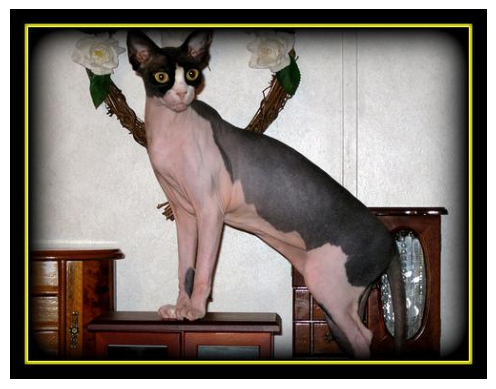

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get the first image name
image_name = os.listdir("/content/train/cat")[0]

# Complete path
image_path = os.path.join("/content/train/cat", image_name)

# Read image
img = mpimg.imread(image_path)

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

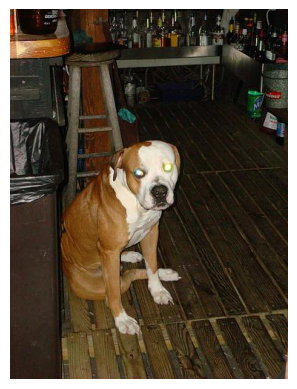

In [ ]:
image_name = os.listdir("/content/train/dog")[0]

image_path = os.path.join("/content/train/dog", image_name)

img = mpimg.imread(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

Saving shiba_inu_132_jpg.rf.d78b9415e906d676483604c844a0c98c.jpg to shiba_inu_132_jpg.rf.d78b9415e906d676483604c844a0c98c.jpg


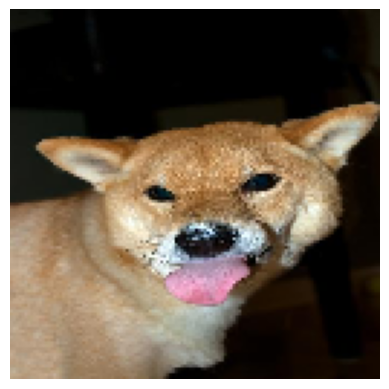

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step

Analyzing Image.....

Prediction : DOG
Confidence : 71.06 %


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


# Upload any image
uploaded = files.upload()


# Get uploaded file name automatically
img_name = list(uploaded.keys())[0]


# Display the image
img = image.load_img(
    img_name,
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()


# Convert image for prediction
img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array/255


# Make prediction
prediction = model.predict(img_array)

prediction_value = prediction[0][0]


# Display result
print("\nAnalyzing Image.....")


if prediction_value > 0.5:

    confidence = prediction_value*100

    print("\nPrediction : DOG")
    print("Confidence :",round(confidence,2),"%")

else:

    confidence = (1-prediction_value)*100

    print("\nPrediction : CAT")
    print("Confidence :",round(confidence,2),"%")